# ESM-C embeddings for the reference tree (PF13853, 6 species)

Recompute `esmc_300m` per-residue embeddings for the 584 reference-tree proteins
(`PF13853.9606_7955_7740_7764_75743_137246.fa`, headers `>{taxid}.{uniprot}`) and save them
to `proteins/reference_tree_esmc_300m_embeddings/`.

Then mean-pool to one 960-d vector per protein and visualise / analyse:
1. **UMAP** (static) coloured by species, with Human split into OR **class 1** / **class 2**.
2. **UMAP** (interactive plotly, saved to HTML).
3. **PCA** with the zero-axes highlighted.
4. **Embedding distance vs phylogenetic (patristic) distance** from the tree.

Human OR class &larr; `HumanTree/human433_OR_classes.csv`; other species coloured by taxon.

> Run on the workstation in the **esmc** environment (same as the GPCR notebook). The final
> distance cell additionally needs `ete4`; if it is not in the esmc env, run that one cell in
> the ete4 kernel (it only reads `df`/`X` already in memory + the tree file).

In [19]:
from pathlib import Path
import torch
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from Bio import SeqIO

# from tqdm.auto import tqdm
# from esm.models.esmc import ESMC
# from esm.sdk.api import ESMProtein, LogitsConfig

# ---- paths (relative to this notebook: Model/Embeddings/) ----
PHYLO      = Path("../../Phylogenetic_Analysis/data")
REF        = PHYLO / "ReferenceTree"
FASTA_PATH = REF / "PF13853.9606_7955_7740_7764_75743_137246.fa"
TREE_PATH  = REF / "PF13853.9606_7955_7740_7764_75743_137246.clustalo.gt01.treefile"
OR_CSV     = PHYLO / "HumanTree/human433_OR_classes.csv"

OUT_DIR = Path("proteins/reference_tree_esmc_300m_embeddings")   # .npy embeddings
FIG_DIR = Path("figures")                                        # saved figures / html
FIG_DIR.mkdir(exist_ok=True)

for p in (FASTA_PATH, TREE_PATH, OR_CSV):
    assert p.exists(), f"Missing input: {p}"
print("Inputs OK ->", FASTA_PATH.name)

Inputs OK -> PF13853.9606_7955_7740_7764_75743_137246.fa


## esm-c — extract per-residue embeddings

In [22]:
def compute_esmc_embeddings(fasta_path, output_dir=OUT_DIR):
    """Per-residue esmc_300m embeddings; one .npy per protein named `<uniprot>.<taxid>.npy`.
    FASTA headers look like `>9606.<uniprot>` (i.e. `<taxid>.<uniprot>`)."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)
    model = ESMC.from_pretrained("esmc_300m").to(device).eval()

    out_dir = Path(output_dir)
    out_dir.mkdir(exist_ok=True, parents=True)

    saved_count = 0
    for rec in tqdm(SeqIO.parse(str(fasta_path), "fasta"), desc="Embedding proteins"):
        header = rec.id                      # "<taxid>.<uniprot>", e.g. "9606.O43749"
        seq    = str(rec.seq)

        try:
            taxid, uniprot = header.split(".", 1)
            filename = f"{taxid}.{uniprot}.npy"
        except ValueError:
            print(f"Skipping malformed header: {header}")
            continue

        protein = ESMProtein(sequence=seq)
        tok = model.encode(protein).to(device)

        with torch.no_grad():
            out = model.logits(tok, LogitsConfig(sequence=True, return_embeddings=True))
            emb = out.embeddings.squeeze(0).cpu().numpy()  # [L+2, 960]

        np.save(out_dir / filename, emb)
        saved_count += 1
        if saved_count % 100 == 0:
            print(f"Saved {saved_count}: {filename}  shape {emb.shape}")

    print(f"Finished. Saved {saved_count} embeddings to {out_dir}")
    return out_dir

In [23]:
emb_dir = compute_esmc_embeddings(FASTA_PATH, output_dir=OUT_DIR)

Device: cuda


Embedding proteins: 100it [00:24,  4.11it/s]

Saved 100: 9606.A6NF89.npy  shape (316, 960)


Embedding proteins: 200it [00:49,  4.00it/s]

Saved 200: 9606.Q8NGC0.npy  shape (364, 960)


...

Saved 400: 9606.Q96R54.npy  shape (316, 960)


Embedding proteins: 500it [02:02,  4.07it/s]

Saved 500: 7955.Q2PRJ4.npy  shape (327, 960)


Embedding proteins: 584it [02:23,  4.06it/s]

Finished. Saved 584 embeddings to proteins/reference_tree_esmc_300m_embeddings


## Load embeddings & mean-pool

Strip BOS/EOS (`emb[1:-1]`) and mean-pool over residues to get one `960`-d vector per protein.
Species are decoded from the taxid prefix of each filename.

In [20]:
emb_dir = OUT_DIR
assert emb_dir.exists(), f"Folder not found: {emb_dir} (run the extraction cell first)"

TAXON_TO_SPECIES = {
    "9606":   "Human",
    "7955":   "Zebrafish",
    "7740":   "Amphioxus",
    "7764":   "Hagfish",
    "75743":  "Catshark",
    "137246": "Bambooshark",
}

rows, X = [], []
npy_files = sorted(emb_dir.glob("*.npy"))
print("Found", len(npy_files), "npy files")
for fp in npy_files:
    tax_id, uniprot = fp.stem.split(".", 1)
    emb = np.load(fp, mmap_mode="r")     # (L+2, 960)
    emb = emb[1:-1]                      # (L, 960) remove BOS/EOS
    X.append(emb.mean(axis=0))           # (960,)
    rows.append({"file": fp.name, "tax_id": tax_id, "uniprot": uniprot,
                 "species": TAXON_TO_SPECIES.get(tax_id, "Other"), "L": emb.shape[0]})

df = pd.DataFrame(rows)
X = np.vstack(X)
print("Loaded:", X.shape, " (n_proteins, emb_dim)")
print(df["species"].value_counts())

Found 584 npy files
Loaded: (584, 960)  (n_proteins, emb_dim)
species
Human          433
Zebrafish      103
Hagfish         43
Bambooshark      2
Catshark         2
Amphioxus        1
Name: count, dtype: int64


## Assign groups + correspondence check

- Human receptors &larr; `human433_OR_classes.csv` (`Class_I` &rarr; *Human (class 1)*, `Class_II` &rarr; *Human (class 2)*).
- All other species keep their taxon name.

The check warns if any Human receptor is missing from the OR-class CSV.

In [21]:
import warnings

# Human OR class from the human OR tree (uniprot -> group label)
orc = pd.read_csv(OR_CSV)
or_label = {"Class_I": "Human (class 1)", "Class_II": "Human (class 2)"}
human_class = {u: or_label[c] for u, c in zip(orc["uniprot"], orc["OR_class"])}

def assign_group(row):
    if row["species"] == "Human":
        return human_class.get(row["uniprot"], "Human (unclassified)")
    return row["species"]

df["group"] = df.apply(assign_group, axis=1)

# correspondence check: every Human receptor should be classified
missing = df.loc[(df["species"] == "Human") & (df["group"] == "Human (unclassified)"), "uniprot"].tolist()
if missing:
    warnings.warn(f"{len(missing)} Human receptor(s) not in {OR_CSV.name}: {missing}")
print(df["group"].value_counts())

GROUP_COLORS = {
    "Human (class 1)":      "#7f1734",
    "Human (class 2)":      "#557c99",
    "Human (unclassified)": "#b97171",   # falls back to the original Human colour (unused: all 433 classified)
    "Zebrafish":            "#2A9D8F",
    "Amphioxus":            "#C4A01D",
    "Hagfish":              "#6A4C93",
    "Catshark":             "#C56E4F",
    "Bambooshark":          "#C56E4F",
}
group_order = ["Human (class 1)", "Human (class 2)", "Human (unclassified)",
               "Zebrafish", "Hagfish", "Catshark", "Bambooshark", "Amphioxus"]
# draw background species first, Human OR classes on top
draw_order = ["Human (class 1)", "Human (class 2)", "Human (unclassified)",
               "Zebrafish", "Hagfish", "Catshark", "Bambooshark", "Amphioxus"]

group
Human (class 2)    371
Zebrafish          103
Human (class 1)     62
Hagfish             43
Bambooshark          2
Catshark             2
Amphioxus            1
Name: count, dtype: int64


## UMAP

In [14]:
import umap
from sklearn.manifold import trustworthiness

reducer = umap.UMAP(n_neighbors=50, min_dist=0.5, metric="cosine", random_state=42)
Z = reducer.fit_transform(X)   # (n, 2)
print("UMAP:", Z.shape)
print(f"Trustworthiness: {trustworthiness(X, Z, n_neighbors=40):.4f}")

/home/izirdeli/.conda/envs/esmc/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: (584, 2)
Trustworthiness: 0.9625


## 1. UMAP — static (matplotlib)

Coloured by `GROUP_COLORS`; background species drawn first, Human OR classes on top.
Exported as SVG + PNG to `figures/`.

/home/izirdeli/anaconda3/envs/ete4/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/izirdeli/anaconda3/envs/ete4/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: (584, 2)
Trustworthiness: 0.9461


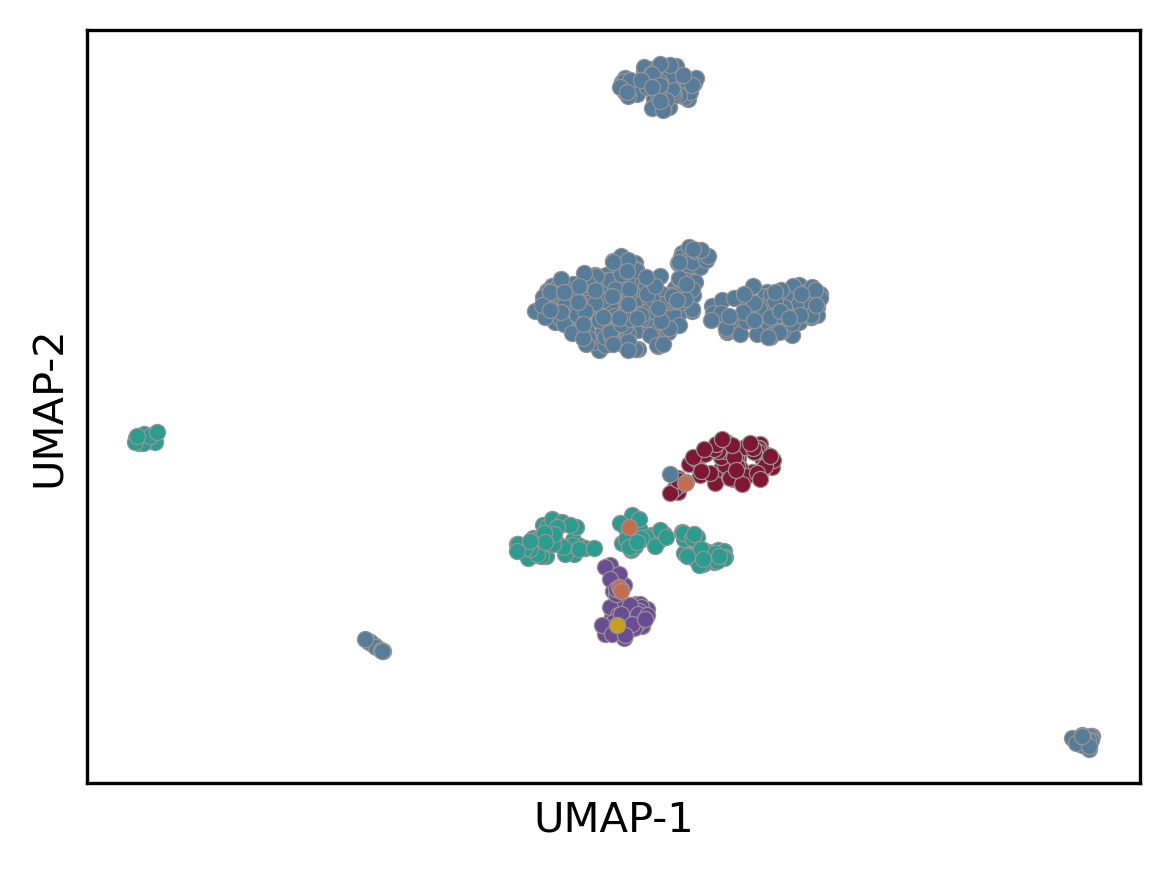

In [10]:
import umap
from sklearn.manifold import trustworthiness

reducer = umap.UMAP(
    n_neighbors=40, 
    min_dist=0.7, 
    metric="cosine",
    n_components=2, 
    random_state=42)

Z = reducer.fit_transform(X)   # (n, 2)
print("UMAP:", Z.shape)
print(f"Trustworthiness: {trustworthiness(X, Z, n_neighbors=40):.4f}")


plot_df = df.copy()
plot_df["UMAP-1"] = Z[:, 0]
plot_df["UMAP-2"] = Z[:, 1]

plt.figure(figsize=(4, 3), dpi=300)
for g in draw_order:
    sub = plot_df[plot_df["group"] == g]
    if sub.empty:
        continue
    plt.scatter(sub["UMAP-1"], sub["UMAP-2"], s=15, alpha=1,
                color=GROUP_COLORS[g], edgecolors="#999494", linewidth=0.3, label=f"{g} (n={len(sub)})")

ax = plt.gca(); ax.set_xticks([]); ax.set_yticks([])
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
#plt.legend(title="group", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=6)
plt.tight_layout()
#plt.savefig(FIG_DIR / "reftree_esmc300m_umap_byclass.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "reftree_esmc300m_umap_byclass.png", bbox_inches="tight", dpi=300)
plt.show()

## 2. UMAP — interactive (plotly)

Same coordinates and colours, hover shows uniprot / species / group / length; saved to HTML.

In [ ]:
import plotly.express as px

fig = px.scatter(
    plot_df, x="UMAP-1", y="UMAP-2", color="group",
    category_orders={"group": group_order}, color_discrete_map=GROUP_COLORS,
    hover_name="uniprot",
    hover_data={"species": True, "group": True, "L": True,
                "UMAP-1": ":.2f", "UMAP-2": ":.2f"},
    title="ESM-C (300m) UMAP — reference tree (Human split into OR class 1 / 2)",
    width=900, height=650,
)
fig.update_traces(marker=dict(size=7, line=dict(width=0.4, color="black")))
fig.update_layout(legend_title_text="group")
html_path = FIG_DIR / "reftree_esmc300m_umap_byclass.html"
fig.write_html(str(html_path)); print("saved:", html_path)
fig.show()

## 3. PCA (zero-axes highlighted)

Linear PCA of the same 960-d mean-pooled embeddings, coloured by the same groups.
The x=0 and y=0 axes are drawn as bold reference lines.

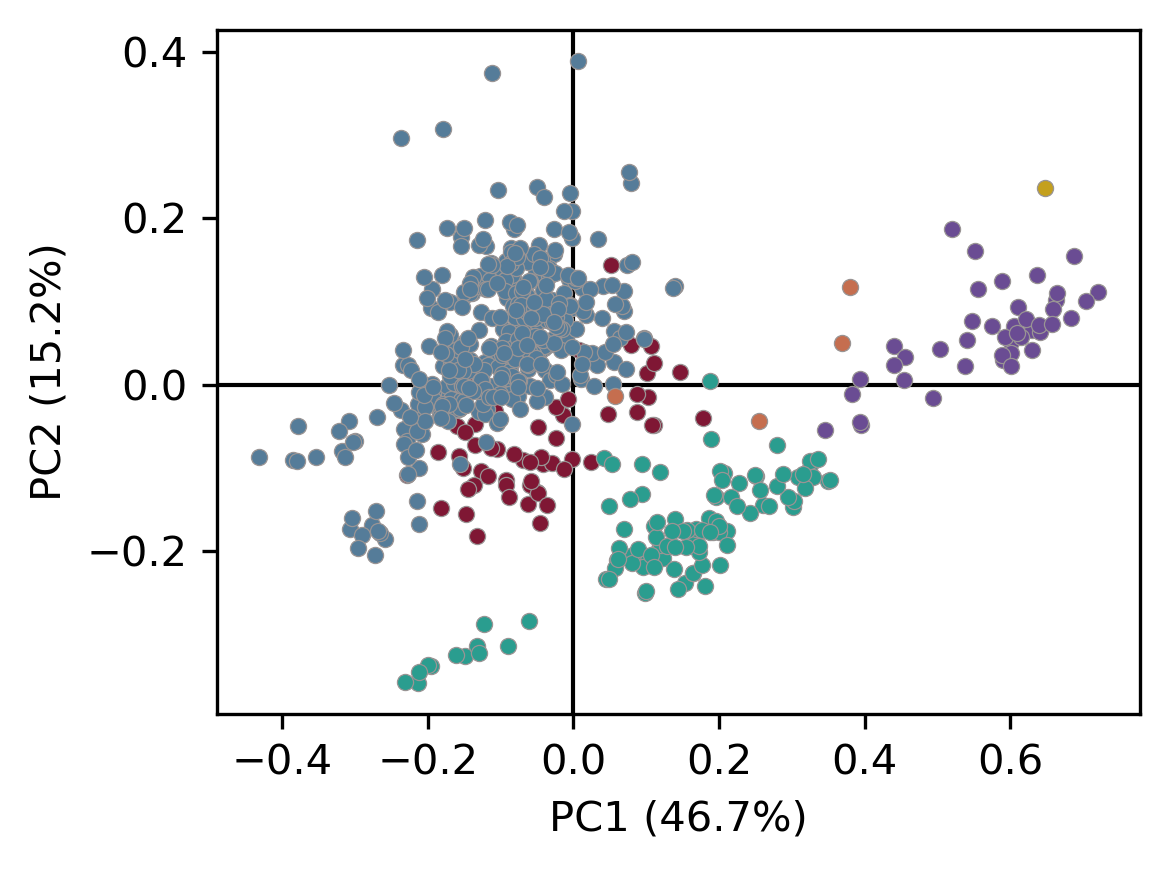

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
P = pca.fit_transform(X)
ev = pca.explained_variance_ratio_ * 100
plot_df["PC1"], plot_df["PC2"] = P[:, 0], P[:, 1]

plt.figure(figsize=(4, 3), dpi=300)
ax = plt.gca()
ax.axhline(0, color="black", lw=1.0, zorder=0)   # highlighted zero-axes
ax.axvline(0, color="black", lw=1.0, zorder=0)
for g in draw_order:
    sub = plot_df[plot_df["group"] == g]
    if sub.empty:
        continue
    plt.scatter(sub["PC1"], sub["PC2"], s=15, alpha=1,
                color=GROUP_COLORS[g], edgecolors="#999494", linewidth=0.3, label=f"{g} (n={len(sub)})", zorder=2)
plt.xlabel(f"PC1 ({ev[0]:.1f}%)"); plt.ylabel(f"PC2 ({ev[1]:.1f}%)")
#plt.legend(title="group", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=6)
plt.tight_layout()
#plt.savefig(FIG_DIR / "reftree_esmc300m_pca_byclass.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "reftree_esmc300m_pca_byclass.png", bbox_inches="tight", dpi=300)
plt.show()

## 4. Embedding distance vs phylogenetic (patristic) distance

For every pair of receptors, compare:
- **phylogenetic distance** = patristic distance (sum of branch lengths between the two leaves)
  from the tree, via `ete4`'s `cophenetic_matrix()` (`parser=1` so internal node labels are
  read as names, not support values).
- **embedding distance** = cosine distance between mean-pooled ESM vectors (matching the UMAP;
  switch `pdist(..., metric=...)` to `"cityblock"` for Manhattan).

The two 584×584 matrices are aligned by leaf id (`<taxid>.<uniprot>`) and their upper triangles
(170,236 unique pairs) are correlated. Pairs are coloured by Human OR-class membership (same
classes as the UMAP, from `human433_OR_classes.csv`): **class 1 × class 1** → class-1 red,
**class 2 × class 2** → class-2 blue, **class 1 × class 2** → the 50/50 blend, everything else
(a pair with ≥1 non-Human receptor) → grey.

> Needs `ete4`. If the esmc env lacks it, run this single cell in the ete4 kernel after the rest
> (`df`, `X`, `GROUP_COLORS` must already be in memory).

pairs: 170,236   Pearson r = 0.718   Spearman rho = 0.724
mix colour: #6a4a66   |   class1-class1=1,891  class2-class2=68,635  class1-class2=23,002  other=76,708


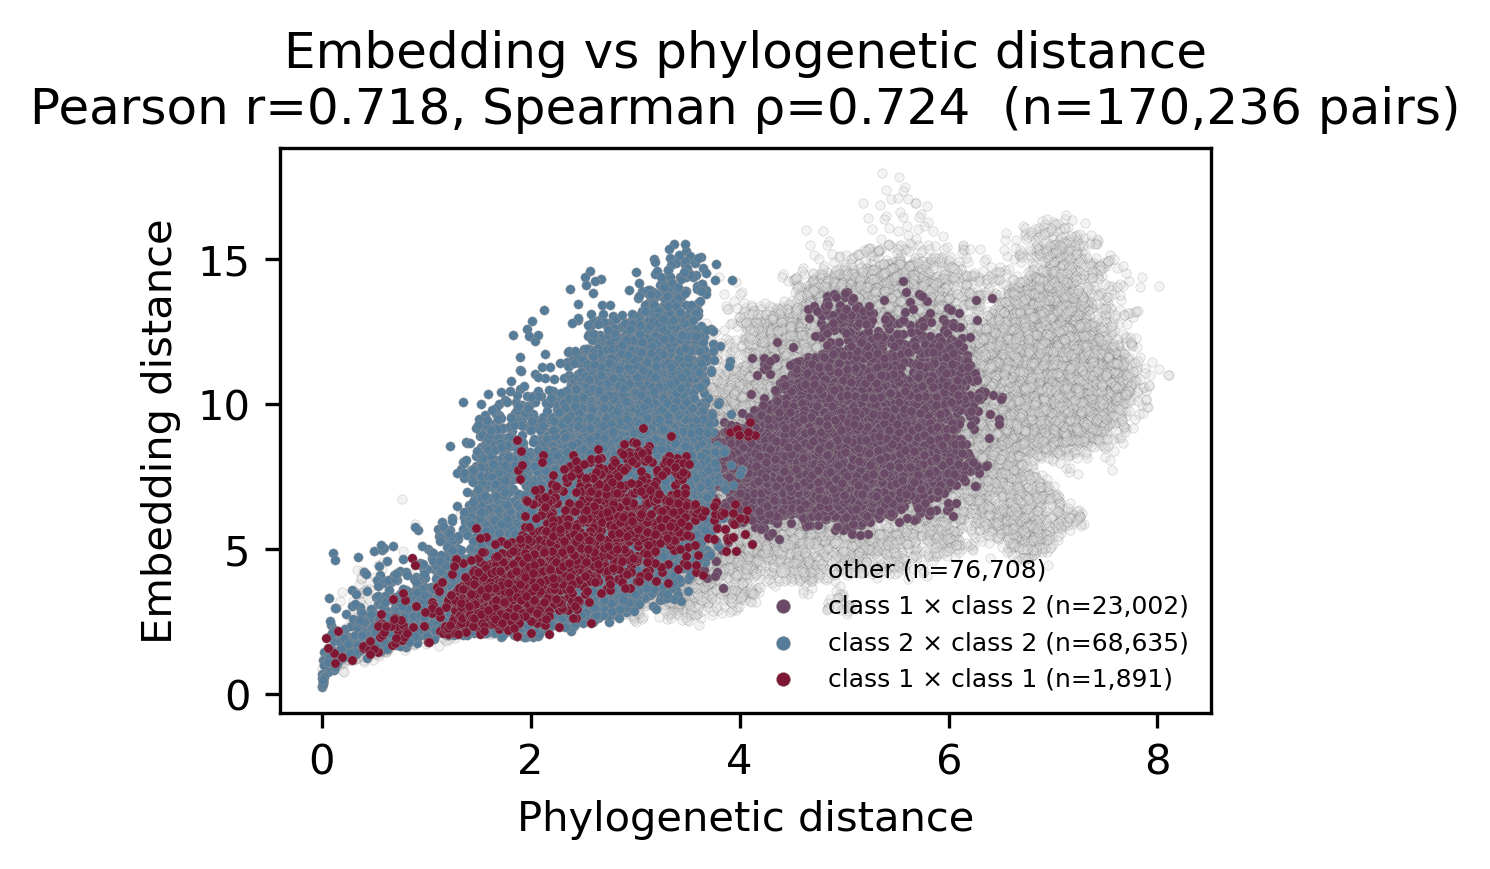

In [18]:
# ---- Embedding distance vs phylogenetic (patristic) distance, coloured by OR-class pair ----
from ete4 import PhyloTree
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr

# patristic distances (branch-length distances between leaves)
# parser=1 -> internal node names (e.g. "node_329") read as names, not support values
phy = PhyloTree(open(TREE_PATH).read(), parser=1)
cophen, leaf_names = phy.cophenetic_matrix()
D_phylo_full = np.asarray(cophen, dtype=float)
name_idx = {n: i for i, n in enumerate(leaf_names)}

# align the tree matrix to the embedding (X / df) order
meta_ids = (df["tax_id"].astype(str) + "." + df["uniprot"].astype(str)).values
assert set(meta_ids) == set(leaf_names), "tree vs embedding id mismatch"
order = [name_idx[i] for i in meta_ids]
D_phylo = D_phylo_full[np.ix_(order, order)]          # now row i == X[i]

# embedding distances (cosine, matching the UMAP metric; use "cityblock" for Manhattan)
D_emb = squareform(pdist(X, metric="cityblock"))   # (n, n) pairwise distances

# upper triangle = unique pairs
iu = np.triu_indices(len(X), k=1)
phylo_d, emb_d = D_phylo[iu], D_emb[iu]

r, _   = pearsonr(phylo_d, emb_d)
rho, _ = spearmanr(phylo_d, emb_d)
print(f"pairs: {len(phylo_d):,}   Pearson r = {r:.3f}   Spearman rho = {rho:.3f}")

# ---- per-receptor Human OR class (from df['group'], same source as the UMAP) ----
group2cls = {"Human (class 1)": "class 1", "Human (class 2)": "class 2"}
cls = np.array([group2cls.get(g) for g in df["group"]], dtype=object)   # None for non-Human

# ---- classify each pair ----
ci, cj = cls[iu[0]], cls[iu[1]]
both1 = (ci == "class 1") & (cj == "class 1")
both2 = (ci == "class 2") & (cj == "class 2")
cross = ((ci == "class 1") & (cj == "class 2")) | ((ci == "class 2") & (cj == "class 1"))
other = ~(both1 | both2 | cross)

RED, BLUE = GROUP_COLORS["Human (class 1)"], GROUP_COLORS["Human (class 2)"]
def hex_blend(h1, h2, t=0.5):
    a = np.array([int(h1[k:k+2], 16) for k in (1, 3, 5)])
    b = np.array([int(h2[k:k+2], 16) for k in (1, 3, 5)])
    return "#%02x%02x%02x" % tuple(np.round((1 - t) * a + t * b).astype(int))
MIX = hex_blend(RED, BLUE, 0.5)   # mix of class-1 red and class-2 blue
print(f"mix colour: {MIX}   |   class1-class1={both1.sum():,}  class2-class2={both2.sum():,}  "
      f"class1-class2={cross.sum():,}  other={other.sum():,}")

plt.figure(figsize=(4, 3), dpi=300)
# background: pairs involving a non-Human receptor
plt.scatter(phylo_d[other], emb_d[other], s=5, alpha=0.3, c="#D9D9D9",
            edgecolors="#312D2D", linewidth=0.1, label=f"other (n={other.sum():,})", rasterized=True)
# OR-class pairs on top
for mask, color, lab in [(cross, MIX,  f"class 1 \u00d7 class 2 (n={cross.sum():,})"),
                         (both2, BLUE, f"class 2 \u00d7 class 2 (n={both2.sum():,})"),
                         (both1, RED,  f"class 1 \u00d7 class 1 (n={both1.sum():,})")]:
    plt.scatter(phylo_d[mask], emb_d[mask], s=5, alpha=1, c=color,
                edgecolors="#999494", linewidth=0.1, label=lab, rasterized=True)

plt.xlabel("Phylogenetic distance")
plt.ylabel("Embedding distance")
plt.title(f"Embedding vs phylogenetic distance\n"
          f"Pearson r={r:.3f}, Spearman \u03c1={rho:.3f}  (n={len(phylo_d):,} pairs)")
plt.legend(fontsize=6, frameon=False, markerscale=1.5, loc="lower right")
plt.tight_layout()
#plt.savefig(FIG_DIR / "reftree_esmc300m_embedding_vs_phylo_distance_byclass.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "reftree_esmc300m_embedding_vs_phylo_distance_byclass.png", bbox_inches="tight", dpi=300)
plt.show()

## 5. Defensible inference — Mantel, per-class slopes (bootstrap bands), partial correlation

Three statistics on the same `phylo_d` / `emb_d` and class masks from the cell above:
1. **Mantel test** (permuting taxa, not pairs) — a permutation p-value for the matrix
   correlation, which the raw Pearson/Spearman cannot give since the 170k pairs are not
   independent. Spearman ≈ Pearson, so the monotonic signal is robust to the curvature.
2. **Per-class slopes with 95% bootstrap bands** — OLS slope of embedding vs phylogenetic
   distance within each pair category; bands from a **receptor-level bootstrap** (resampling
   taxa, so they respect non-independence). The class 1 vs class 2 slope *difference* is the
   actual evolutionary claim and is tested directly.
3. **Partial correlation conditioning on pair-category** — how much of the association survives
   once the trivial "cross-class pairs are far apart" component is removed.

> Runtime: `PERMS=99999` makes the Mantel test slow (~10–15 min for the two permutation loops).
> Lower `PERMS` for a quick look. Needs the previous distance cell to have run.

[1] Mantel (999 perms):  Spearman r=0.724 (p=0.001000)   Pearson r=0.718 (p=0.001000)
[2] per-class slopes (point estimate, 95% bootstrap CI over receptors, B=500):
      class 1 × class 1   slope=1.693  CI[1.418, 1.964]
      class 2 × class 2   slope=2.482  CI[2.277, 2.715]
      class 1 × class 2   slope=0.524  CI[0.192, 0.861]
      other               slope=1.021  CI[0.923, 1.125]
      class1 - class2 slope = -0.789  CI[-1.148, -0.429]  bootstrap p=0.000
[3] partial corr | pair-category:  Spearman 0.724 -> 0.471   Pearson 0.718 -> 0.496


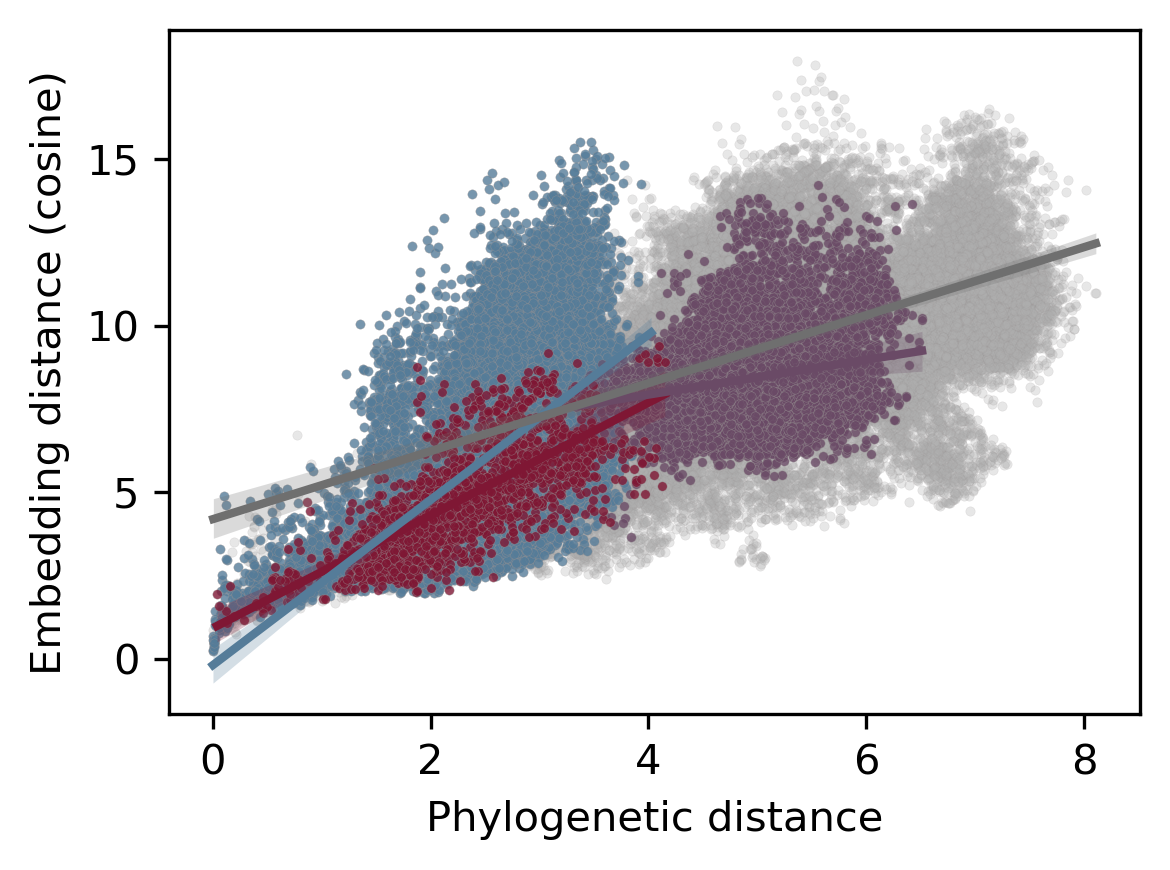

In [29]:
# ---- Defensible inference: Mantel, per-class slopes (bootstrap bands), partial correlation ----
from scipy.stats import rankdata

n = len(X)
GREY = "#B0B0B0"
cat_defs = [("class 1 × class 1", both1, RED),
            ("class 2 × class 2", both2, BLUE),
            ("class 1 × class 2", cross, MIX),
            ("other",             other, GREY)]

# ---------- 1. Mantel test (permute taxa) ----------
def _rank_mat(Dm):
    R = np.zeros_like(Dm); R[iu] = rankdata(Dm[iu]); return R + R.T

def mantel(Dx, Dy, perms=999, method="spearman", seed=0):
    if method == "spearman":
        Dx, Dy = _rank_mat(Dx), _rank_mat(Dy)
    x = Dx[iu]; obs = np.corrcoef(x, Dy[iu])[0, 1]
    rng = np.random.default_rng(seed); ge = 0
    for _ in range(perms):
        p = rng.permutation(n)
        ge += np.corrcoef(x, Dy[np.ix_(p, p)][iu])[0, 1] >= obs
    return obs, (ge + 1) / (perms + 1)

PERMS = 999   # ~10-15 min total; lower for a quick look
m_rho, p_rho = mantel(D_phylo, D_emb, PERMS, "spearman")
m_r,   p_r   = mantel(D_phylo, D_emb, PERMS, "pearson")

# ---------- 2. per-class slopes + receptor-level bootstrap bands ----------
def slope_int(x, y):
    m, b = np.linalg.lstsq(np.vstack([x, np.ones_like(x)]).T, y, rcond=None)[0]
    return m, b

point = {lab: slope_int(phylo_d[mk], emb_d[mk]) for lab, mk, _ in cat_defs}

B = 500
rng = np.random.default_rng(1)
boot = {lab: {"m": [], "b": []} for lab, _, _ in cat_defs}
diff_c1_c2 = []
for _ in range(B):
    bs = rng.integers(0, n, n)                         # resample receptors (taxa)
    Dp = D_phylo[np.ix_(bs, bs)][iu]; De = D_emb[np.ix_(bs, bs)][iu]
    cb = cls[bs]; cbi, cbj = cb[iu[0]], cb[iu[1]]
    b1 = (cbi == "class 1") & (cbj == "class 1")
    b2 = (cbi == "class 2") & (cbj == "class 2")
    cx = ((cbi == "class 1") & (cbj == "class 2")) | ((cbi == "class 2") & (cbj == "class 1"))
    ot = ~(b1 | b2 | cx)
    nz = Dp > 0                                        # drop duplicate-origin zero-distance pairs
    s = {}
    for lab, mk in [("class 1 × class 1", b1), ("class 2 × class 2", b2),
                    ("class 1 × class 2", cx), ("other", ot)]:
        mm = mk & nz
        if mm.sum() > 2:
            m, b = slope_int(Dp[mm], De[mm]); boot[lab]["m"].append(m); boot[lab]["b"].append(b); s[lab] = m
    if "class 1 × class 1" in s and "class 2 × class 2" in s:
        diff_c1_c2.append(s["class 1 × class 1"] - s["class 2 × class 2"])

diff_c1_c2 = np.array(diff_c1_c2)
d_lo, d_hi = np.percentile(diff_c1_c2, [2.5, 97.5])
p_diff = 2 * min((diff_c1_c2 > 0).mean(), (diff_c1_c2 < 0).mean())

# ---------- 3. partial correlation conditioning on pair-category ----------
pairtype = np.where(both1, "c1", np.where(both2, "c2", np.where(cross, "cx", "ot")))
Z = np.hstack([np.ones((len(pairtype), 1)),
               pd.get_dummies(pairtype, drop_first=True).values.astype(float)])
def _resid(y):  return y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
def partial(x, y): return np.corrcoef(_resid(x), _resid(y))[0, 1]
raw_r   = np.corrcoef(phylo_d, emb_d)[0, 1]
raw_rho = np.corrcoef(rankdata(phylo_d), rankdata(emb_d))[0, 1]
par_r   = partial(phylo_d.astype(float), emb_d.astype(float))
par_rho = partial(rankdata(phylo_d).astype(float), rankdata(emb_d).astype(float))

# ---------- report ----------
print(f"[1] Mantel ({PERMS} perms):  Spearman r={m_rho:.3f} (p={p_rho:.6f})   "
      f"Pearson r={m_r:.3f} (p={p_r:.6f})")
print(f"[2] per-class slopes (point estimate, 95% bootstrap CI over receptors, B={B}):")
for lab, _, _ in cat_defs:
    arr = np.array(boot[lab]["m"]); lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"      {lab:18}  slope={point[lab][0]:.3f}  CI[{lo:.3f}, {hi:.3f}]")
print(f"      class1 - class2 slope = {point['class 1 × class 1'][0]-point['class 2 × class 2'][0]:.3f}  "
      f"CI[{d_lo:.3f}, {d_hi:.3f}]  bootstrap p={p_diff:.3f}")
print(f"[3] partial corr | pair-category:  Spearman {raw_rho:.3f} -> {par_rho:.3f}   "
      f"Pearson {raw_r:.3f} -> {par_r:.3f}")

# ---------- plot: per-class regression lines + bootstrap confidence bands ----------
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# scatter: big groups first (faint); class 1 last and more opaque so its 1.9k red dots stay visible
mask_of = {lab: mk for lab, mk, _ in cat_defs}
col_of  = {lab: col for lab, _, col in cat_defs}
scatter_style = {
    "other":             dict(s=5, alpha=0.3),
    "class 2 × class 2": dict(s=5, alpha=0.8),
    "class 1 × class 2": dict(s=5, alpha=0.8),
    "class 1 × class 1": dict(s=5, alpha=0.8),
}
for lab in ["other", "class 2 × class 2", "class 1 × class 2", "class 1 × class 1"]:
    mk = mask_of[lab]
    ax.scatter(phylo_d[mk], emb_d[mk], c=col_of[lab], edgecolors="#999494", linewidth=0.1,
               rasterized=True, **scatter_style[lab])

for lab, mk, col in cat_defs:
    xg = np.linspace(phylo_d[mk].min(), phylo_d[mk].max(), 100)
    ms = np.array(boot[lab]["m"]); bs_ = np.array(boot[lab]["b"])
    preds = ms[:, None] * xg[None, :] + bs_[:, None]          # (B, grid)
    lo, hi = np.percentile(preds, [2.5, 97.5], axis=0)
    line_c = "#6f6f6f" if lab == "other" else col
    ax.fill_between(xg, lo, hi, color=line_c, alpha=0.25, lw=0)
    ax.plot(xg, point[lab][0] * xg + point[lab][1], color=line_c, lw=2,
            label=f"{lab} (slope {point[lab][0]:.2f})")
ax.set_xlabel("Phylogenetic distance")
ax.set_ylabel("Embedding distance (cosine)")
#ax.set_title(f"Per-class slopes ±95% bootstrap band\n"
#             f"Mantel ρ={m_rho:.6f} (p={p_rho:.6f}); partial ρ|class={par_rho:.6f}")
#ax.legend(fontsize=6, frameon=False, loc="lower right")
plt.tight_layout()
#plt.savefig(FIG_DIR / "reftree_esmc300m_dist_perclass_slopes.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "reftree_esmc300m_dist_perclass_slopes.png", bbox_inches="tight", dpi=300)
plt.show()

[1] Mantel (999 perms):  Spearman r=0.724 (p=0.001000)   Pearson r=0.718 (p=0.001000)
[2] per-class slopes (point estimate, 95% bootstrap CI over receptors, B=500):
      class 1 × class 1   slope=1.693  CI[1.418, 1.964]
      class 2 × class 2   slope=2.482  CI[2.277, 2.715]
      class 1 × class 2   slope=0.524  CI[0.192, 0.861]
      other               slope=1.021  CI[0.923, 1.125]
      class1 - class2 slope = -0.789  CI[-1.148, -0.429]  bootstrap p=0.000
[3] partial corr | pair-category:  Spearman 0.724 -> 0.471   Pearson 0.718 -> 0.496


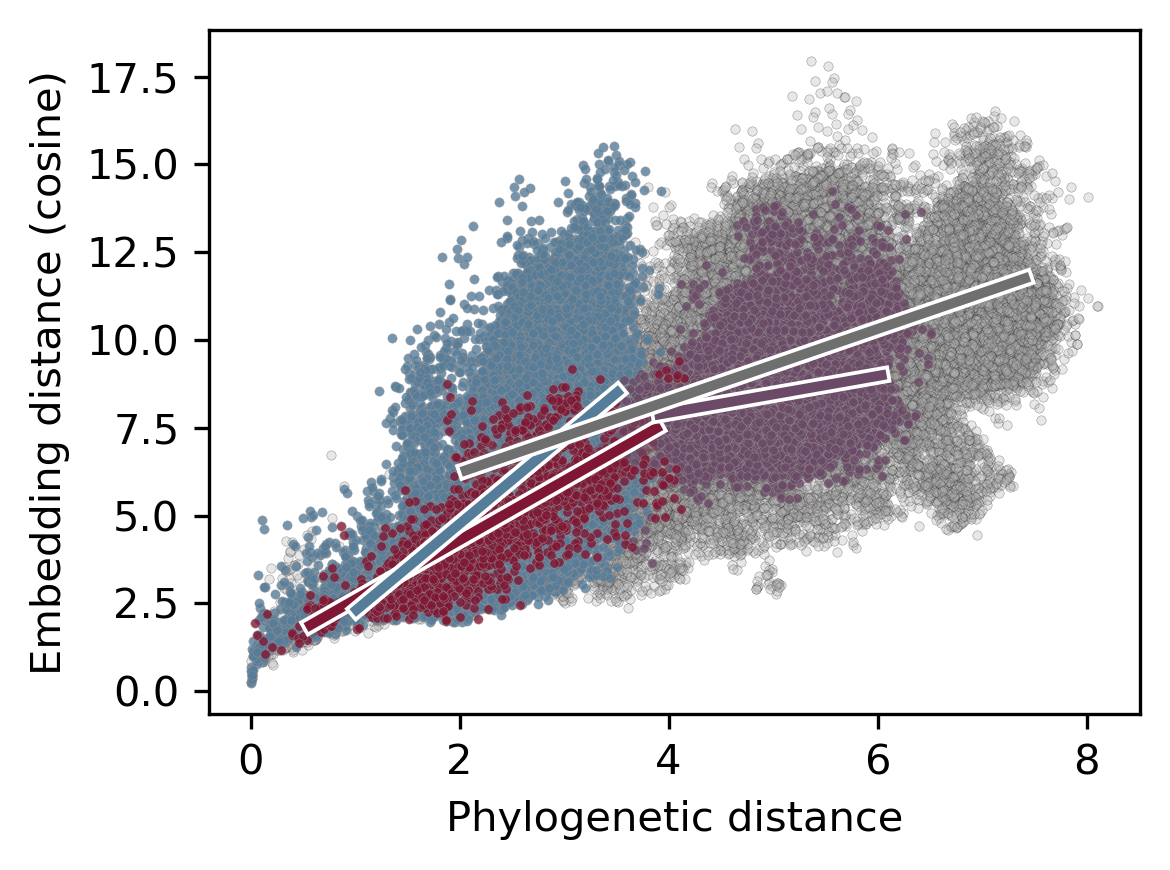

In [32]:
# ---- Defensible inference: Mantel, per-class slopes (bootstrap bands), partial correlation ----
from scipy.stats import rankdata
from matplotlib.colors import to_rgba
import matplotlib.patheffects as pe

n = len(X)
GREY = "#B0B0B0"
cat_defs = [("class 1 × class 1", both1, RED),
            ("class 2 × class 2", both2, BLUE),
            ("class 1 × class 2", cross, MIX),
            ("other",             other, GREY)]

# ---------- 1. Mantel test (permute taxa) ----------
def _rank_mat(Dm):
    R = np.zeros_like(Dm); R[iu] = rankdata(Dm[iu]); return R + R.T

def mantel(Dx, Dy, perms=999, method="spearman", seed=0):
    if method == "spearman":
        Dx, Dy = _rank_mat(Dx), _rank_mat(Dy)
    x = Dx[iu]; obs = np.corrcoef(x, Dy[iu])[0, 1]
    rng = np.random.default_rng(seed); ge = 0
    for _ in range(perms):
        p = rng.permutation(n)
        ge += np.corrcoef(x, Dy[np.ix_(p, p)][iu])[0, 1] >= obs
    return obs, (ge + 1) / (perms + 1)

PERMS = 999   # ~10-15 min total; lower for a quick look
m_rho, p_rho = mantel(D_phylo, D_emb, PERMS, "spearman")
m_r,   p_r   = mantel(D_phylo, D_emb, PERMS, "pearson")

# ---------- 2. per-class slopes + receptor-level bootstrap bands ----------
def slope_int(x, y):
    m, b = np.linalg.lstsq(np.vstack([x, np.ones_like(x)]).T, y, rcond=None)[0]
    return m, b

point = {lab: slope_int(phylo_d[mk], emb_d[mk]) for lab, mk, _ in cat_defs}

B = 500
rng = np.random.default_rng(1)
boot = {lab: {"m": [], "b": []} for lab, _, _ in cat_defs}
diff_c1_c2 = []
for _ in range(B):
    bs = rng.integers(0, n, n)                         # resample receptors (taxa)
    Dp = D_phylo[np.ix_(bs, bs)][iu]; De = D_emb[np.ix_(bs, bs)][iu]
    cb = cls[bs]; cbi, cbj = cb[iu[0]], cb[iu[1]]
    b1 = (cbi == "class 1") & (cbj == "class 1")
    b2 = (cbi == "class 2") & (cbj == "class 2")
    cx = ((cbi == "class 1") & (cbj == "class 2")) | ((cbi == "class 2") & (cbj == "class 1"))
    ot = ~(b1 | b2 | cx)
    nz = Dp > 0                                        # drop duplicate-origin zero-distance pairs
    s = {}
    for lab, mk in [("class 1 × class 1", b1), ("class 2 × class 2", b2),
                    ("class 1 × class 2", cx), ("other", ot)]:
        mm = mk & nz
        if mm.sum() > 2:
            m, b = slope_int(Dp[mm], De[mm]); boot[lab]["m"].append(m); boot[lab]["b"].append(b); s[lab] = m
    if "class 1 × class 1" in s and "class 2 × class 2" in s:
        diff_c1_c2.append(s["class 1 × class 1"] - s["class 2 × class 2"])

diff_c1_c2 = np.array(diff_c1_c2)
d_lo, d_hi = np.percentile(diff_c1_c2, [2.5, 97.5])
p_diff = 2 * min((diff_c1_c2 > 0).mean(), (diff_c1_c2 < 0).mean())

# ---------- 3. partial correlation conditioning on pair-category ----------
pairtype = np.where(both1, "c1", np.where(both2, "c2", np.where(cross, "cx", "ot")))
Z = np.hstack([np.ones((len(pairtype), 1)),
               pd.get_dummies(pairtype, drop_first=True).values.astype(float)])
def _resid(y):  return y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
def partial(x, y): return np.corrcoef(_resid(x), _resid(y))[0, 1]
raw_r   = np.corrcoef(phylo_d, emb_d)[0, 1]
raw_rho = np.corrcoef(rankdata(phylo_d), rankdata(emb_d))[0, 1]
par_r   = partial(phylo_d.astype(float), emb_d.astype(float))
par_rho = partial(rankdata(phylo_d).astype(float), rankdata(emb_d).astype(float))

# ---------- report ----------
print(f"[1] Mantel ({PERMS} perms):  Spearman r={m_rho:.3f} (p={p_rho:.6f})   "
      f"Pearson r={m_r:.3f} (p={p_r:.6f})")
print(f"[2] per-class slopes (point estimate, 95% bootstrap CI over receptors, B={B}):")
for lab, _, _ in cat_defs:
    arr = np.array(boot[lab]["m"]); lo, hi = np.percentile(arr, [2.5, 97.5])
    print(f"      {lab:18}  slope={point[lab][0]:.3f}  CI[{lo:.3f}, {hi:.3f}]")
print(f"      class1 - class2 slope = {point['class 1 × class 1'][0]-point['class 2 × class 2'][0]:.3f}  "
      f"CI[{d_lo:.3f}, {d_hi:.3f}]  bootstrap p={p_diff:.3f}")
print(f"[3] partial corr | pair-category:  Spearman {raw_rho:.3f} -> {par_rho:.3f}   "
      f"Pearson {raw_r:.3f} -> {par_r:.3f}")

# ---------- plot: per-class regression lines + bootstrap confidence bands ----------
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# scatter: big groups first (faint); class 1 last and more opaque so its 1.9k red dots stay visible
mask_of = {lab: mk for lab, mk, _ in cat_defs}
col_of  = {lab: col for lab, _, col in cat_defs}

scatter_style = {
    "other":             dict(s=5, alpha=0.3),
    "class 2 × class 2": dict(s=5, alpha=0.8),
    "class 1 × class 2": dict(s=5, alpha=0.8),
    "class 1 × class 1": dict(s=5, alpha=0.8),
}
edge_of = {                       # per-category marker edge colour
    "class 1 × class 1": "#999494",
    "class 2 × class 2": "#999494",
    "class 1 × class 2": "#999494",
    "other":             "#312D2D",
}

draw_order = ["other", "class 2 × class 2", "class 1 × class 2", "class 1 × class 1"]
for lab in draw_order:
    mk = mask_of[lab]; st = scatter_style[lab]
    ax.scatter(phylo_d[mk], emb_d[mk],
               facecolors=to_rgba(col_of[lab],  st["alpha"]),          # alpha on the FACE only
               edgecolors=to_rgba(edge_of[lab], min(1.0, st["alpha"] + 0.3)),  # edge a touch more opaque
               linewidth=0.1,                                          
               s=st["s"], rasterized=True, zorder=1)

for lab, mk, col in cat_defs:
    xlo, xhi = np.percentile(phylo_d[mk], [1, 99])     # don't draw the line past real support
    xg = np.linspace(xlo, xhi, 100)
    ms = np.array(boot[lab]["m"]); bs_ = np.array(boot[lab]["b"])
    preds = ms[:, None] * xg[None, :] + bs_[:, None]
    lo, hi = np.percentile(preds, [2.5, 97.5], axis=0)
    line_c = "#6f6f6f" if lab == "other" else col
    ax.fill_between(xg, lo, hi, color=line_c, alpha=0.30, lw=0, zorder=2)
    ax.plot(xg, point[lab][0] * xg + point[lab][1], color=line_c, lw=2.4, zorder=3,
            path_effects=[pe.Stroke(linewidth=4.2, foreground="white"), pe.Normal()],
            label=f"{lab} (slope {point[lab][0]:.2f})")
    
ax.set_xlabel("Phylogenetic distance")
ax.set_ylabel("Embedding distance (cosine)")
#ax.set_title(f"Per-class slopes ±95% bootstrap band\n"
#             f"Mantel ρ={m_rho:.6f} (p={p_rho:.6f}); partial ρ|class={par_rho:.6f}")
#ax.legend(fontsize=6, frameon=False, loc="lower right")
plt.tight_layout()
#plt.savefig(FIG_DIR / "reftree_esmc300m_dist_perclass_slopes.svg", bbox_inches="tight", dpi=300)
#plt.savefig(FIG_DIR / "reftree_esmc300m_dist_perclass_slopes.png", bbox_inches="tight", dpi=300)
plt.show()